In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/SoyaReview.csv")
df.head()

,web_scraper_order,web_scraper_start_url,Name,Title,Review,Star,Verified,Date
0,1771222379-1,https://www.amazon.in/product-reviews/B09GH5H2...,karen,Great Meat substitute,Really loved the kit . Easy to use and tastes...,5.0 out of 5 stars,Verified Purchase,Reviewed in India on 4 January 2022
1,1771222379-2,https://www.amazon.in/product-reviews/B09GH5H2...,Rupali,Taste like soya only,Saw many reviews of YouTube and decided to giv...,1.0 out of 5 stars,Verified Purchase,Reviewed in India on 3 June 2022
2,1771222379-3,https://www.amazon.in/product-reviews/B09GH5H2...,Technocrat,This keema is tasty and so convenient.,We loved this product to bits (pun intended)! ...,4.0 out of 5 stars,Verified Purchase,Reviewed in India on 14 January 2022
3,1771222379-4,https://www.amazon.in/product-reviews/B09GH5H2...,Leona,The flavours are melting on my tongue!,Tastes veryyyyy similar to meat but no cruelty...,5.0 out of 5 stars,Verified Purchase,Reviewed in India on 6 March 2022
4,1771222379-5,https://www.amazon.in/product-reviews/B09GH5H2...,Amarnath Banerjee,Too Many Spices !,The spices included with the pack must cost mo...,3.0 out of 5 stars,Verified Purchase,Reviewed in India on 4 June 2022


In [6]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00


In [7]:
from transformers import pipeline
sentiment_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [8]:
custom_lexicon = {
    "rubbery": -2,
    "meaty": +2,
    "aftertaste": -1,
    "bland": -2,
    "juicy": +2,
    "realistic": +3,
    "chemical": -3
}

In [10]:
analyzer = SentimentIntensityAnalyzer()
analyzer.lexicon.update(custom_lexicon)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [13]:
from sklearn.decomposition import LatentDirichletAllocation

In [15]:
!pip install bertopic
from bertopic import BERTopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [21]:
def aspect_polarity_vector(text):
    scores = []
    text_lower = str(text).lower()

    for aspect, keywords in aspects.items():
        if any(k in text_lower for k in keywords):
            s = analyzer.polarity_scores(text_lower)
            scores.extend([s['pos'], s['neg']])
        else:
            scores.extend([0, 0])  # no mention

    return scores

df['aspect_vector'] = df['Review'].apply(aspect_polarity_vector)

In [19]:
aspects = {
    "taste": ["taste", "flavour", "flavor", "bland", "yummy"],
    "texture": ["texture", "rubbery", "chewy", "soft", "hard"],
    "smell": ["smell", "odor", "odour", "aroma"],
    "price": ["price", "cost", "expensive", "cheap"],
    "health": ["healthy", "protein", "processed", "nutrition"]
}

In [22]:
def aspect_polarity_vector(text):
    scores = []
    text_lower = str(text).lower()

    for aspect, keywords in aspects.items():
        if any(k in text_lower for k in keywords):
            s = analyzer.polarity_scores(text_lower)
            scores.extend([s['pos'], s['neg']])
        else:
            scores.extend([0, 0])  # no mention

    return scores

df['aspect_vector'] = df['Review'].apply(aspect_polarity_vector)

In [24]:
!pip install pandas vaderSentiment

In [26]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load your CSV
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SoyaReview.csv')

# Check columns
print(df.columns)

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Function to compute polarity vector
def get_polarity_vector(text):
    scores = analyzer.polarity_scores(str(text))
    return scores  # returns dict with pos, neg, neu, compound

# Apply to your review column (change 'review_text' if needed)
df['polarity'] = df['Review'].apply(get_polarity_vector)

# Expand polarity dict into separate columns
polarity_df = pd.json_normalize(df['polarity'])

# Merge back to main dataframe
df = pd.concat([df, polarity_df], axis=1)

# Show output
df[['Review', 'pos', 'neg', 'neu', 'compound']].head(10)

Index(['web_scraper_order', 'web_scraper_start_url', 'Name', 'Title', 'Review',
       'Star', 'Verified', 'Date'],
      dtype='object')


,Review,pos,neg,neu,compound
0,Really loved the kit . Easy to use and tastes...,0.268,0.000,0.732,0.9585
1,Saw many reviews of YouTube and decided to giv...,0.056,0.090,0.855,-0.4965
2,We loved this product to bits (pun intended)! ...,0.183,0.029,0.788,0.9358
3,Tastes veryyyyy similar to meat but no cruelty...,0.361,0.000,0.639,0.6716
4,The spices included with the pack must cost mo...,0.126,0.000,0.874,0.7345
5,This is just soyabean same as other soyabean c...,0.065,0.104,0.831,-0.7059
6,"Really good texture and excellent quality, val...",0.508,0.000,0.492,0.8516
7,The product came in a good box with all the in...,0.061,0.098,0.841,-0.6859
8,NaN,0.000,0.000,1.000,0.0000
9,Damn I liked it!! It's quite tasty. One star l...,0.181,0.032,0.786,0.8185


In [28]:
df['polarity_vector'] = df.apply(
    lambda row: [row['pos'], row['neg'], row['neu'], row['compound']], axis=1
)

df[['Review', 'polarity_vector']].head(5)

,Review,polarity_vector
0,Really loved the kit . Easy to use and tastes...,"[0.268, 0.0, 0.732, 0.9585]"
1,Saw many reviews of YouTube and decided to giv...,"[0.056, 0.09, 0.855, -0.4965]"
2,We loved this product to bits (pun intended)! ...,"[0.183, 0.029, 0.788, 0.9358]"
3,Tastes veryyyyy similar to meat but no cruelty...,"[0.361, 0.0, 0.639, 0.6716]"
4,The spices included with the pack must cost mo...,"[0.126, 0.0, 0.874, 0.7345]"


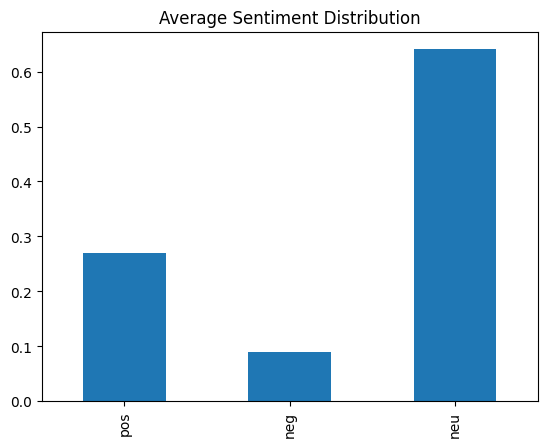

In [29]:
import matplotlib.pyplot as plt

df[['pos','neg','neu']].mean().plot(kind='bar', title='Average Sentiment Distribution')
plt.show()

In [31]:
def label_sentiment(compound):
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment_label'] = df['compound'].apply(label_sentiment)

df[['Review', 'compound', 'sentiment_label']].head(10)

,Review,compound,sentiment_label
0,Really loved the kit . Easy to use and tastes...,0.9585,Positive
1,Saw many reviews of YouTube and decided to giv...,-0.4965,Negative
2,We loved this product to bits (pun intended)! ...,0.9358,Positive
3,Tastes veryyyyy similar to meat but no cruelty...,0.6716,Positive
4,The spices included with the pack must cost mo...,0.7345,Positive
5,This is just soyabean same as other soyabean c...,-0.7059,Negative
6,"Really good texture and excellent quality, val...",0.8516,Positive
7,The product came in a good box with all the in...,-0.6859,Negative
8,NaN,0.0000,Neutral
9,Damn I liked it!! It's quite tasty. One star l...,0.8185,Positive
